In [17]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import warnings
warnings.filterwarnings('ignore')


df = pd.read_csv('loan_prediction.csv')   

print("Shape:", df.shape)
print("\nColumns:", df.columns.tolist())
print("\nFirst 5 rows:")
df.head()

print("\nData Types:\n", df.dtypes)
print("\nMissing Values:\n", df.isnull().sum())
print("\nBasic Statistics:\n", df.describe())

#  Handle Missing Values 

df['LoanAmount'].fillna(df['LoanAmount'].median(), inplace=True)
df['Loan_Amount_Term'].fillna(df['Loan_Amount_Term'].mode()[0], inplace=True)
df['Credit_History'].fillna(df['Credit_History'].mode()[0], inplace=True)

# Fill categorical columns with mode
for col in ['Gender', 'Married', 'Dependents', 'Self_Employed']:
    df[col].fillna(df[col].mode()[0], inplace=True)

print("\nMissing Values After Cleaning:\n", df.isnull().sum())


Shape: (614, 13)

Columns: ['Loan_ID', 'Gender', 'Married', 'Dependents', 'Education', 'Self_Employed', 'ApplicantIncome', 'CoapplicantIncome', 'LoanAmount', 'Loan_Amount_Term', 'Credit_History', 'Property_Area', 'Loan_Status']

First 5 rows:

Data Types:
 Loan_ID               object
Gender                object
Married               object
Dependents            object
Education             object
Self_Employed         object
ApplicantIncome        int64
CoapplicantIncome    float64
LoanAmount           float64
Loan_Amount_Term     float64
Credit_History       float64
Property_Area         object
Loan_Status           object
dtype: object

Missing Values:
 Loan_ID               0
Gender               13
Married               3
Dependents           15
Education             0
Self_Employed        32
ApplicantIncome       0
CoapplicantIncome     0
LoanAmount           22
Loan_Amount_Term     14
Credit_History       50
Property_Area         0
Loan_Status           0
dtype: int64

Basic St

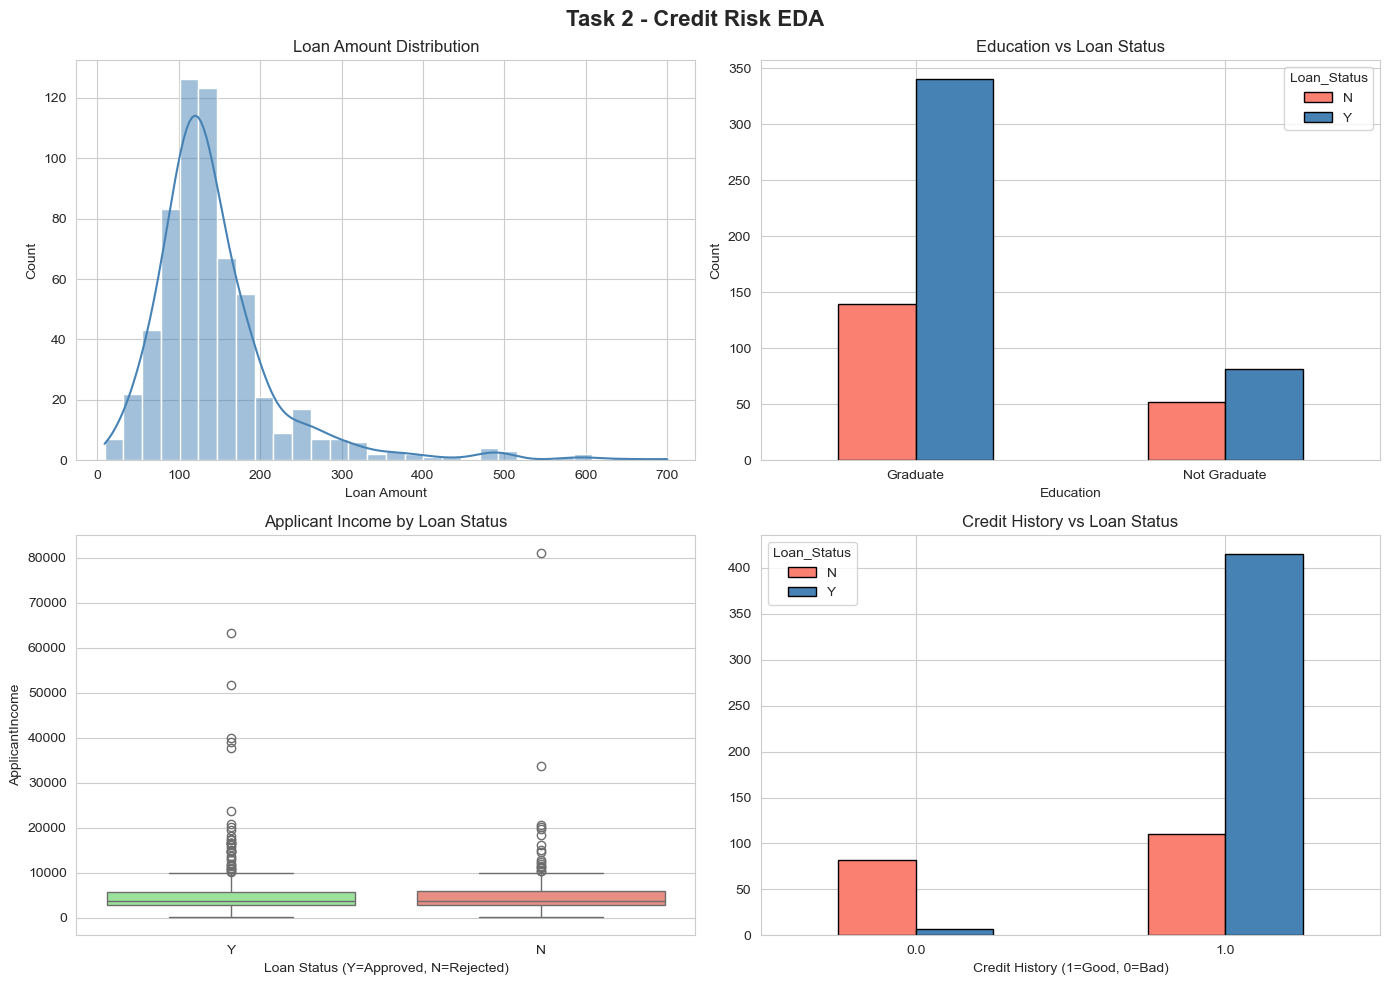

In [18]:
sns.set_style("whitegrid")
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Task 2 - Credit Risk EDA', fontsize=16, fontweight='bold')

# Plot 1: Loan Amount Distribution
sns.histplot(df['LoanAmount'], kde=True, ax=axes[0, 0], color='steelblue', bins=30)
axes[0, 0].set_title('Loan Amount Distribution')
axes[0, 0].set_xlabel('Loan Amount')

# Plot 2: Education vs Loan Status
edu_counts = df.groupby(['Education', 'Loan_Status']).size().unstack()
edu_counts.plot(kind='bar', ax=axes[0, 1], color=['salmon', 'steelblue'], edgecolor='black')
axes[0, 1].set_title('Education vs Loan Status')
axes[0, 1].set_xlabel('Education')
axes[0, 1].set_ylabel('Count')
axes[0, 1].tick_params(axis='x', rotation=0)

# Plot 3: Applicant Income Distribution by Loan Status
sns.boxplot(x='Loan_Status', y='ApplicantIncome', data=df, ax=axes[1, 0],
            palette={'Y': 'lightgreen', 'N': 'salmon'})
axes[1, 0].set_title('Applicant Income by Loan Status')
axes[1, 0].set_xlabel('Loan Status (Y=Approved, N=Rejected)')

# Plot 4: Credit History vs Loan Status
credit_counts = df.groupby(['Credit_History', 'Loan_Status']).size().unstack()
credit_counts.plot(kind='bar', ax=axes[1, 1], color=['salmon', 'steelblue'], edgecolor='black')
axes[1, 1].set_title('Credit History vs Loan Status')
axes[1, 1].set_xlabel('Credit History (1=Good, 0=Bad)')
axes[1, 1].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.savefig('task2_eda.png', dpi=150)
plt.show()



In [19]:
le = LabelEncoder()
categorical_cols = ['Gender', 'Married', 'Dependents', 'Education',
                    'Self_Employed', 'Property_Area', 'Loan_Status']

df_encoded = df.copy()
for col in categorical_cols:
    df_encoded[col] = le.fit_transform(df_encoded[col])

df_encoded.drop('Loan_ID', axis=1, inplace=True)


In [20]:

# Feature Selection
X = df_encoded.drop('Loan_Status', axis=1)
y = df_encoded['Loan_Status']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"\nTraining samples: {X_train.shape[0]}, Test samples: {X_test.shape[0]}")



Training samples: 491, Test samples: 123


In [21]:
# Model 1: Logistic Regression
lr_model = LogisticRegression(max_iter=1000, random_state=42)
lr_model.fit(X_train, y_train)
lr_pred = lr_model.predict(X_test)

# Model 2: Decision Tree
dt_model = DecisionTreeClassifier(max_depth=5, random_state=42)
dt_model.fit(X_train, y_train)
dt_pred = dt_model.predict(X_test)

# Evaluate Models
print("\n" + "="*50)
print("LOGISTIC REGRESSION RESULTS")
print("="*50)
print(f"Accuracy: {accuracy_score(y_test, lr_pred):.4f}")
print("\nClassification Report:\n", classification_report(y_test, lr_pred))

print("\n" + "="*50)
print("DECISION TREE RESULTS")
print("="*50)
print(f"Accuracy: {accuracy_score(y_test, dt_pred):.4f}")
print("\nClassification Report:\n", classification_report(y_test, dt_pred))



LOGISTIC REGRESSION RESULTS
Accuracy: 0.8618

Classification Report:
               precision    recall  f1-score   support

           0       0.96      0.58      0.72        38
           1       0.84      0.99      0.91        85

    accuracy                           0.86       123
   macro avg       0.90      0.78      0.81       123
weighted avg       0.88      0.86      0.85       123


DECISION TREE RESULTS
Accuracy: 0.8211

Classification Report:
               precision    recall  f1-score   support

           0       0.81      0.55      0.66        38
           1       0.82      0.94      0.88        85

    accuracy                           0.82       123
   macro avg       0.82      0.75      0.77       123
weighted avg       0.82      0.82      0.81       123



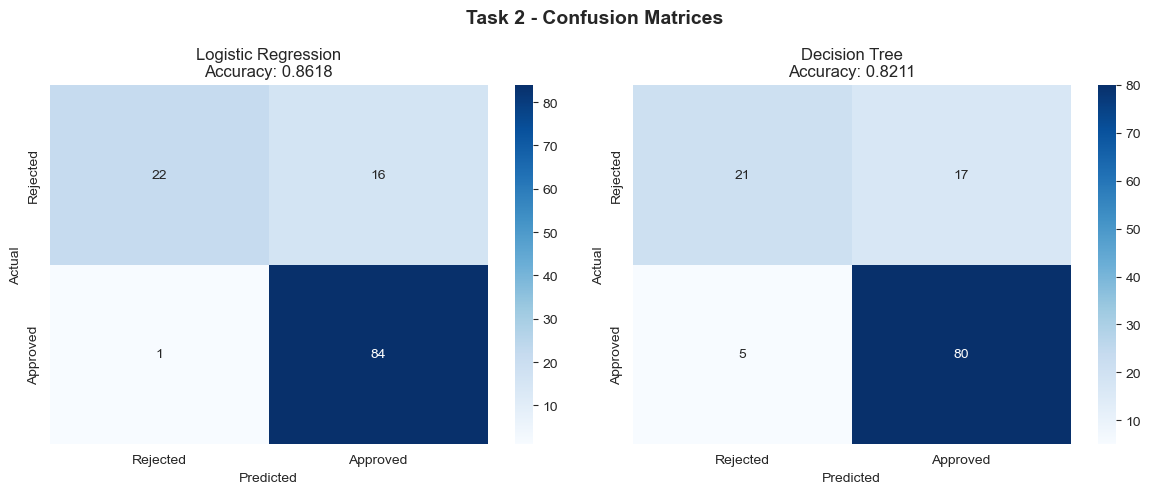

In [22]:

# Confusion Matrices 
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle('Task 2 - Confusion Matrices', fontsize=14, fontweight='bold')

for ax, pred, title in zip(
    axes,
    [lr_pred, dt_pred],
    ['Logistic Regression', 'Decision Tree']
):
    cm = confusion_matrix(y_test, pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['Rejected', 'Approved'],
                yticklabels=['Rejected', 'Approved'])
    ax.set_title(f'{title}\nAccuracy: {accuracy_score(y_test, pred):.4f}')
    ax.set_ylabel('Actual')
    ax.set_xlabel('Predicted')

plt.tight_layout()
plt.savefig('task2_confusion_matrix.png', dpi=150)
plt.show()


In [23]:

# Conclusion 
print("\n" + "="*50)
print("CONCLUSION")
print("="*50)
print(f"Logistic Regression Accuracy: {accuracy_score(y_test, lr_pred):.4f}")
print(f"Decision Tree Accuracy      : {accuracy_score(y_test, dt_pred):.4f}")
print("\nKey Insights:")
print("- Credit History is the strongest predictor of loan approval.")
print("- Applicants with higher income tend to get loans approved.")
print("- Graduates have a slightly higher loan approval rate.")


CONCLUSION
Logistic Regression Accuracy: 0.8618
Decision Tree Accuracy      : 0.8211

Key Insights:
- Credit History is the strongest predictor of loan approval.
- Applicants with higher income tend to get loans approved.
- Graduates have a slightly higher loan approval rate.
